## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**.
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

# **Información general**

In [102]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# importar librerías

In [103]:
# cargar archivos
traffic = pd.read_csv('tomtom_traffic.csv')
eco = pd.read_csv('oecd_city_economy.csv') #completa el código

In [104]:
print(traffic.head()) # mostrar las primeras 5 filas de traffic

  Country       City            UpdateTimeUTC  JamsDelay  TrafficIndexLive  \
0     ARE  abu-dhabi  2025-01-13 04:01:30.001      650.7              36.0   
1     ARE  abu-dhabi  2025-01-13 03:46:00.000      540.4              30.0   
2     ARE  abu-dhabi  2025-01-13 02:46:30.000       71.8               7.0   
3     ARE  abu-dhabi  2025-01-13 01:46:30.001        8.2               2.0   
4     ARE  abu-dhabi  2025-01-13 00:01:30.000        1.1               1.0   

   JamsLengthInKms  JamsCount  TrafficIndexWeekAgo     UpdateTimeUTCWeekAgo  \
0            109.1      162.0                 30.0  2025-01-06 04:01:30.000   
1            101.4      136.0                 27.0  2025-01-06 03:46:30.001   
2             18.9       23.0                  6.0  2025-01-06 02:46:30.000   
3              4.1        2.0                  2.0  2025-01-06 01:46:30.000   
4              0.2        1.0                  1.0  2025-01-06 00:01:30.000   

   TravelTimeLivePer10KmsMins  TravelTimeHistoricPer10Km

In [105]:
print(eco.head())# mostrar las primeras 5 filas de eco

   Year            City    Country City GDP/capita Unemployment %  \
0  2023    buenos-aires  Argentina       15.782,00           6.2%   
1  2023       sao-paulo     Brazil       14.475,00           9.1%   
2  2023  rio-de-janeiro     Brazil       13.142,00           9.8%   
3  2023        brasilia     Brazil       15.999,00           8.3%   
4  2023        salvador     Brazil        8.761,00          13.1%   

  PM2.5 (μg/m³) Population (M)  
0          15,2          15,30  
1         29,50          22,50  
2         19,10          13,60  
3         13,50           4,70  
4         16,00           3,90  


In [106]:
# Examinar la estructura de traffic

print(traffic.info())
print(traffic.head(3))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

**Comentarios**

Este dataframe cuenta con 12 columnas: cuatro de tipo object y ocho de tipo float.
Las columnas UpdateTimeUTC y UpdateTimeUTCWeekAgo  se encuentran actualmente en formato object (texto), cuando en realidad representan información temporal.

Por otro lado, no se identificaron datos ausentes ni valores nulos en ninguna de las columnas.

**Conclusión**

Se recomienda convertir estas columnas UpdateTimeUTC y UpdateTimeUTCWeekAgo a tipo Datetime


In [107]:
# Examinar la estructura de eco
print(eco.info())
print(eco.head(3))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB
None
   Year            City    Country City GDP/capita Unemployment %  \
0  2023    buenos-aires  Argentina       15.782,00           6.2%   
1  2023       sao-paulo     Brazil       14.475,00           9.1%   
2  2023  rio-de-janeiro     Brazil       13.142,00           9.8%   

  PM2.5 (μg/m³) Population (M)  
0          15,2          15,30  
1         29,50          22,50  
2         19,10          13,60  


**Comentarios**

Este dataframe cuenta con 7 columnas: una de tipo int y seis de tipo object.
La mayoría de las columnas están en formato texto; sin embargo, algunas representan valores numéricos que actualmente no pueden ser utilizados directamente en el análisis.

Por otro lado, no se identificaron datos ausentes ni valores nulos en ninguna de las columnas.

**Conclusión**

Se recomienda convertir las columnas GDP per capita, Unemployment %, PM2.5 y Population a tipo float, ya que contienen valores numéricos. Esto permitirá realizar cálculos, comparaciones y análisis estadísticos de manera adecuada.



### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [108]:
# Estandarizar los nombres de las columnas de traffic
traffic = traffic.rename(columns={
    "Country": "country",
    "City": "city",
    "UpdateTimeUTC": "update_time_utc",
    "JamsDelay": "jams_delay",
    "TrafficIndexLive": "traffic_index_live",
    "JamsLengthInKms": "jams_length_in_kms",
    "JamsCount": "jams_count",
    "TrafficIndexWeekAgo": "traffic_index_week_ago",
    "UpdateTimeUTCWeekAgo": "update_time_utc_week_ago",
    "TravelTimeLivePer10KmsMins": "travel_time_live_per_10kms_mins",
    "TravelTimeHistoricPer10KmsMins": "travel_time_historic_per_10kms_mins",
    "MinsDelay": "mins_delay"})

# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')

In [109]:

# Estandarizar los nombres de las columnas de eco
eco = eco.rename(columns={
    "Year": "year",
    "Country": "country",
    "City": "city",
    "City GDP/capita": "city_gdp_capita",
    "Unemployment %": "unemployment_%",
    "PM2.5 (μg/m³)": "pm25",
    "Population (M)": "population_m"
})
# verificar cambios
eco.columns


Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_%', 'pm25',
       'population_m'],
      dtype='object')

**Comentario**

Se aplica el formato snake_case a los nombres de las columnas con el fin de estandarizarlos y facilitar su manipulación durante el análisis.

<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [110]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic ["update_time_utc"],errors="coerce")
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic ["update_time_utc_week_ago"],errors="coerce")


# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   country                              1004464 non-null  object        
 1   city                                 1004464 non-null  object        
 2   update_time_utc                      1004464 non-null  datetime64[ns]
 3   jams_delay                           1004464 non-null  float64       
 4   traffic_index_live                   1004464 non-null  float64       
 5   jams_length_in_kms                   1004464 non-null  float64       
 6   jams_count                           1004464 non-null  float64       
 7   traffic_index_week_ago               1004464 non-null  float64       
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins      1004464 non-null  fl


**Comentario**

Se convierten las columnas de fecha del dataframe traffic a tipo datetime utilizando pd.to_datetime(). Se emplea el parámetro errors='coerce', lo que permite transformar valores no convertibles en NaT, facilitando su identificación y tratamiento posterior.

Este paso es fundamental para asegurar que los tipos de datos sean coherentes con su uso analítico, evitar errores en operaciones posteriores y permitir la realización de cálculos fiables.

In [111]:
# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = (eco["city_gdp_capita"].astype(str).str.replace('.', '').str.replace(',', '.').astype(float))
eco['unemployment_pct'] = (eco["unemployment_%"].astype(str).str.replace('%','').astype(float))
eco['population_m'] = (eco["population_m"].astype(str).str.replace(',','.').astype(float))


# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m']*1000000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_%    30 non-null     object 
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
 7   unemployment_pct  30 non-null     float64
 8   population        30 non-null     float64
dtypes: float64(4), int64(1), object(4)
memory usage: 2.2+ KB


,year,city,country,city_gdp_capita,unemployment_%,pm25,population_m,unemployment_pct,population
0,2023,buenos-aires,Argentina,15782.0,6.2%,"15,2",15.3,6.2,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1%,"29,50",22.5,9.1,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8%,"19,10",13.6,9.8,13600000.0


**Comentario**

Se eliminaron símbolos como porcentajes (%), comas y otros caracteres no numéricos en las columnas correspondientes. Esta limpieza es fundamental para evitar errores en la conversión de tipos de datos y garantizar que las operaciones matemáticas se realicen correctamente.

Posteriormente, las columnas fueron convertidas a tipos numéricos adecuados para su análisis.

Finalmente, se creó la columna population a partir de population_m, multiplicando por 1,000,000, con el objetivo de expresar la población en unidades absolutas. Esta transformación facilita la interpretación, comparación y análisis de los datos.

In [112]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic["update_time_utc"].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


**Comentario**

Extracción de la variable temporal (año)

Dado que el DataFrame traffic no contaba con una columna de año, se utilizó el atributo .dt.year sobre la columna update_time_utc para extraer esta información y crear una nueva columna llamada year.

Este paso permite facilitar el análisis temporal de los datos, así como realizar agregaciones y comparaciones por año de manera más eficiente.

In [113]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic["year"]==2024].copy()
eco_2024 = eco.copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_%,pm25,population_m,unemployment_pct,population
0,2023,buenos-aires,Argentina,15782.0,6.2%,"15,2",15.3,6.2,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1%,"29,50",22.5,9.1,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8%,"19,10",13.6,9.8,13600000.0
3,2023,brasilia,Brazil,15999.0,8.3%,"13,50",4.7,8.3,4700000.0
4,2023,salvador,Brazil,8761.0,13.1%,"16,00",3.9,13.1,3900000.0


**Comentario**

Filtrado de datos por año

Se filtraron ambos DataFrames para conservar únicamente los registros correspondientes al año 2024.

Adicionalmente, se utilizó el método .copy() con el objetivo de evitar advertencias como SettingWithCopyWarning y asegurar que las modificaciones posteriores no afecten a los DataFrames originales. Esto permite trabajar con copias independientes y garantiza un flujo de datos más seguro y controlado.



<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [114]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 =(traffic_2024.groupby(["city","country","year"]).agg({'jams_delay':'mean',
'traffic_index_live':'mean', 'jams_length_in_kms':'mean','jams_count':'mean','mins_delay':'mean',
'travel_time_live_per_10kms_mins':'mean', 'travel_time_historic_per_10kms_mins':'mean'}).reset_index())

traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


**Comentario**

🎯Objetivo: Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

Como el dataset de tráfico contiene múltiples registros por ciudad. En esta parte se calculó promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.
Solo de las métricas de tráfico más relevantes.

Esta agregación permite obtener una representación más estable del comportamiento general y es un paso adecuado dentro del proceso de análisis descriptivo.

Se utilizó el promedio (mean) como medida de agregación para resumir las métricas de tráfico, permitiendo comparar el comportamiento general entre ciudades. Aunque es sensible a valores extremos, resulta adecuado para capturar variaciones relevantes en los niveles de congestión.

In [115]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


**Comentario**

Identificación de ciudades con mayor congestión.

Se ordenaron los valores de la columna jams_delay de forma descendente, con el objetivo de identificar las ciudades con mayor nivel de congestión en 2024.

A partir de este análisis, se observa que Mexico City presenta el mayor tiempo promedio de retraso por tráfico. Este resultado es consistente con las características de la ciudad, ya que se trata de una de las áreas metropolitanas más grandes y densamente pobladas de la región, lo que contribuye a altos niveles de congestión y demanda de movilidad.

Este hallazgo refuerza la relevancia de analizar la movilidad urbana en grandes ciudades, donde el tráfico puede impactar significativamente la productividad y calidad de vida.

<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [116]:

# Seleccionar columnas clave de tráfico y economía
traffic_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_historic_per_10kms_mins']

eco_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[['city','country','year','jams_delay','traffic_index_live','travel_time_live_per_10kms_mins']].copy()
eco_2024_small = eco_2024[['city','year','city_gdp_capita','unemployment_pct','population']].copy()

# Unir datasets
eco_2024_small = eco_2024_small.rename(columns={'year': 'year'})
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner')


# Mostrar las primeras 5 filas
merged.head()



,city,country,year,jams_delay,traffic_index_live,travel_time_live_per_10kms_mins,city_gdp_capita,unemployment_pct,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,18.304538,11124.0,9.5,6100000.0
1,bogota,COL,2024,1141.552364,37.614273,24.992185,11442.0,10.0,11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,13.338658,16251.0,7.8,4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,17.907916,18117.0,7.2,15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,17.258700,12381.0,8.2,3700000.0


**Comentario**

🎯 Objetivo: Combinar la información de tráfico y economía en un solo DataFrame para analizar la relación entre movilidad urbana y condiciones económicas.

Se seleccionaron únicamente las columnas más relevantes de cada dataset, con el fin de enfocar el análisis en las variables clave y reducir la complejidad del conjunto de datos.

Posteriormente, se realizó una unión (merge) utilizando city y year como llaves, ya que son las variables comunes entre ambos DataFrames y permiten alinear correctamente la información temporal y geográfica.

El resultado es un nuevo DataFrame denominado merged, el cual integra indicadores de tráfico y variables económicas, facilitando el análisis conjunto y la identificación de posibles relaciones entre ambas dimensiones.

Se utilizó un inner join para asegurar que solo se incluyeran observaciones con información completa en ambos datasets.

**VISUALIZACIONES GRAFICAS**

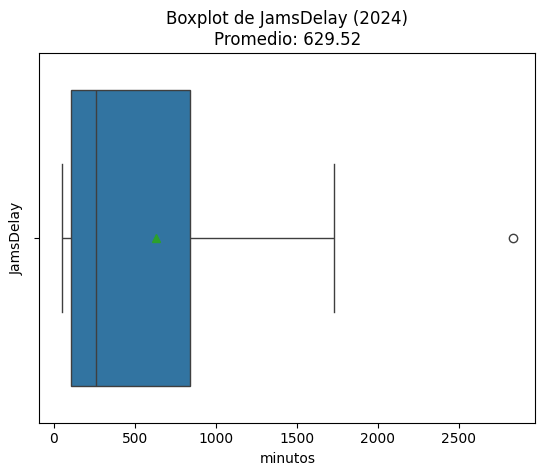

In [117]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
sns.boxplot(data=merged,x='jams_delay',showmeans=True)
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.xlabel('minutos')
plt.ylabel('JamsDelay')
plt.show()


**Comentario**

Análisis de distribución del tráfico (jams_delay) – 2024

Herramienta: Se utilizó la librería seaborn para la visualización.

Se empleó un boxplot para analizar la distribución de la variable jams_delay en ciudades de LATAM durante 2024. Este tipo de gráfico permite identificar la mediana, la dispersión de los datos, así como la presencia de valores atípicos (outliers).

El promedio de retraso es de aproximadamente 629.52 minutos anuales. Sin embargo, la mayoría de los valores se concentran por debajo de los 1,000 minutos, lo que indica que algunas ciudades presentan niveles de congestión considerablemente más altos que el resto.

La distribución muestra una asimetría positiva (sesgo a la derecha), evidenciada por la presencia de valores elevados que extienden la cola superior. Esto sugiere que existen ciudades con niveles de tráfico significativamente superiores al promedio.

Asimismo, se identifica al menos un valor atípico por encima de los 2,500 minutos, lo que refuerza la existencia de alta variabilidad en la congestión urbana entre ciudades.

**Conclusión**

La presencia de asimetría sugiere que el promedio puede estar influenciado por valores extremos, por lo que complementar el análisis con la mediana resulta recomendable.

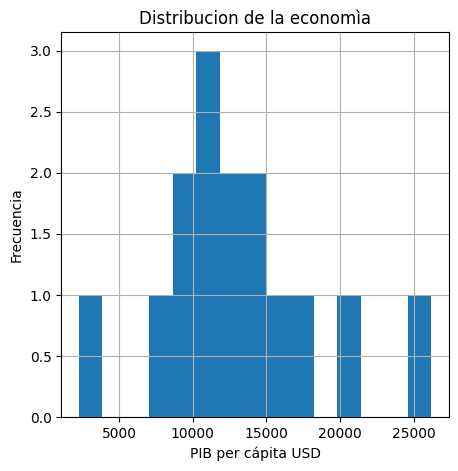

In [118]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
merged['city_gdp_capita'].hist(bins=15,figsize=(5,5))
plt.title('Distribucion de la economìa')
plt.xlabel('PIB per cápita USD')
plt.ylabel('Frecuencia')
plt.show()




**Comentario**

Análisis de distribución económica (city_gdp_capita) – 2024

Herramienta: Se utilizó la librería matplotlib.pyplot.

Se empleó un histograma para analizar la distribución del PIB per cápita (city_gdp_capita) entre ciudades de LATAM en 2024. Este tipo de visualización permite identificar la concentración de valores, la dispersión y posibles asimetrías en los datos.

Se observa que la mayoría de las ciudades presentan un PIB per cápita en el rango aproximado de 10,000 a 15,000 USD, lo que indica una concentración en niveles económicos medios dentro de la muestra.

Asimismo, existen valores en los extremos —por debajo de 5,000 USD y por encima de 25,000 USD— que sugieren la presencia de alta variabilidad entre ciudades. Esto indica diferencias significativas en el nivel económico, más que una “distribución anormal”.

**Conclusión**

La forma del histograma sugiere una ligera asimetría, lo que refleja que no todas las ciudades se distribuyen de manera uniforme en términos de PIB per cápita.

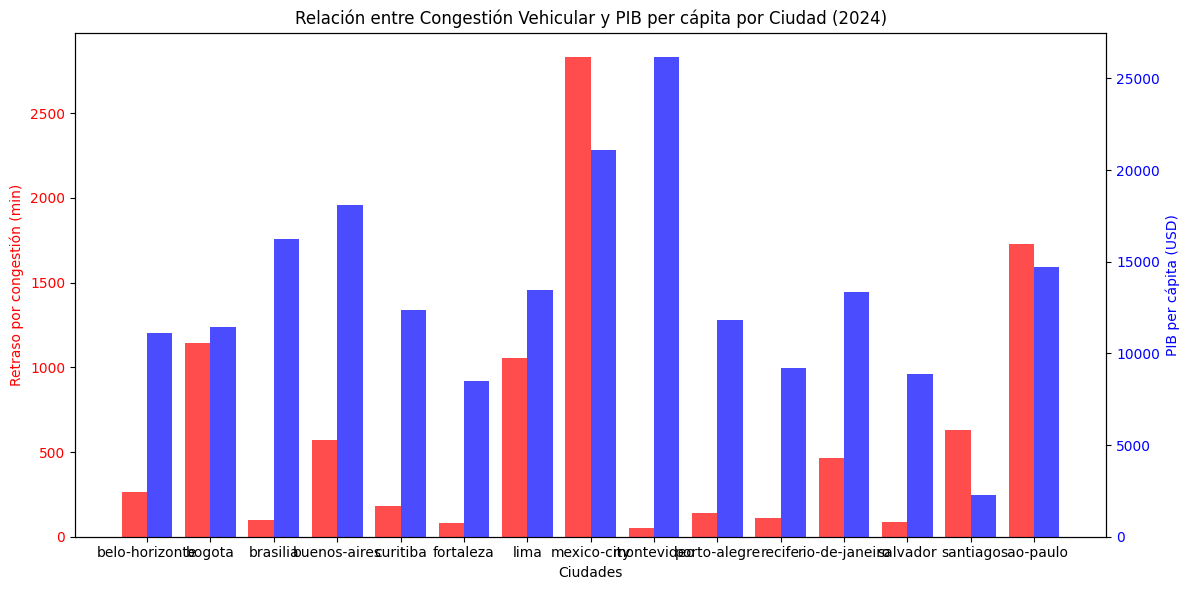

In [119]:
# Filtrar solo las ciudades que tienen datos económicos (sin NaN)
merged_clean = merged.dropna(subset=['city_gdp_capita'])

# Crear gráfico de barras dobles
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primer eje para jams_delay
x = range(len(merged_clean))
ax1.bar([i - 0.2 for i in x], merged_clean['jams_delay'], width=0.4,
        label='Retraso por congestión (min)', color='red', alpha=0.7)
ax1.set_xlabel('Ciudades')
ax1.set_ylabel('Retraso por congestión (min)', color='red')
ax1.tick_params(axis='y', labelcolor='red')

# Segundo eje para city_gdp_capita
ax2 = ax1.twinx()
ax2.bar([i + 0.2 for i in x], merged_clean['city_gdp_capita'], width=0.4,
        label='PIB per cápita (USD)', color='blue', alpha=0.7)
ax2.set_ylabel('PIB per cápita (USD)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Configurar etiquetas del eje x
plt.xticks(x, merged_clean['city'], rotation=45, ha='right')
plt.title('Relación entre Congestión Vehicular y PIB per cápita por Ciudad (2024)')
plt.tight_layout()
plt.show()


### 🧠 **Comentario**

Relación entre congestión vehicular y PIB per cápita (2024)

Herramienta: Se utilizó la librería matplotlib.pyplot para comparar ambas variables mediante un gráfico de barras por ciudad.

El objetivo de esta visualización es explorar la posible relación entre la congestión vehicular (jams_delay) y el nivel económico (city_gdp_capita). Para ello, ambas variables se representaron en un mismo gráfico utilizando ejes diferenciados.

A partir del análisis visual, no se observa una relación lineal clara entre el PIB per cápita y la congestión. Existen casos que siguen una posible tendencia (mayor PIB asociado a menor congestión), como Montevideo; sin embargo, también hay excepciones importantes como Mexico City, que presenta altos niveles en ambas variables.

Esto sugiere que la relación entre economía y movilidad urbana es compleja y está influenciada por múltiples factores adicionales, como la densidad poblacional, la infraestructura de transporte y la planificación urbana.

**Conclusiones generales**

Relación entre PIB y congestión

No se identifica una relación lineal consistente entre ambas variables. Aunque algunos casos sugieren una tendencia inversa, existen suficientes excepciones que impiden generalizar esta relación.
Ciudades con alta congestión y menor nivel económico
Ciudades como Bogotá y Lima presentan niveles elevados de congestión junto con niveles económicos medios, lo que puede indicar oportunidades de mejora en infraestructura de transporte.

Mejores indicadores combinados

Montevideo destaca por presentar bajo nivel de congestión y alto PIB per cápita. Buenos Aires también muestra un balance favorable en comparación con otras ciudades.
Interpretación general
Los resultados indican que el nivel económico por sí solo no explica los niveles de congestión. Es necesario considerar variables adicionales para entender la movilidad urbana de manera integral.

**Recomendaciones de inversión**

Las ciudades con alta congestión y niveles económicos medios, como Bogotá y Lima, podrían ser prioritarias para inversión en infraestructura de transporte, ya que mejoras en movilidad podrían tener un impacto positivo en la productividad y calidad de vida.

No obstante, se recomienda complementar este análisis con variables adicionales (densidad poblacional, transporte público, expansión urbana) antes de tomar decisiones de inversión.

In [120]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

In [121]:
from google.colab import files
files.download("ladb_mobility_economy_2024_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>